In [20]:
from sklearn.datasets import make_moons
from sampling.vanilla.train import train_nets
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch

In [21]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [22]:
# 1. Generate Two Moons
n_samples = 2000
# noise=0.05 gives distinct clean moons; noise=0.1 is fuzzier
raw_data, _ = make_moons(n_samples=n_samples, noise=0.05, random_state=42)

# 2. Standardize Data (Crucial for SDE/Score stability)
# Centers the moons around (0,0) with std dev ~1
data_t = torch.tensor(raw_data, dtype=torch.float32)
mean = data_t.mean(dim=0)
std = data_t.std(dim=0)
data_t = (data_t - mean) / std

# 3. Create Loader
loader = DataLoader(
    TensorDataset(data_t), batch_size=1024, shuffle=True, drop_last=True
)

In [23]:
# # 1. Generate Interleaving Spirals
# def make_spirals(n_samples=2000, noise=0.05):
#     n = n_samples // 2
#     theta = np.sqrt(np.random.rand(n)) * 4 * np.pi

#     r = theta
#     x1 = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)

#     x2 = np.stack([-r * np.cos(theta), -r * np.sin(theta)], axis=1)

#     X = np.concatenate([x1, x2], axis=0)
#     X += noise * np.random.randn(*X.shape)

#     return X


# raw_data = make_spirals(n_samples=2000, noise=0.05)

# # 2. Standardize Data (important for score stability)
# data_t = torch.tensor(raw_data, dtype=torch.float32)
# mean = data_t.mean(dim=0)
# std = data_t.std(dim=0)
# data_t = (data_t - mean) / std

# # 3. Create Loader
# loader = DataLoader(
#     TensorDataset(data_t), batch_size=1024, shuffle=True, drop_last=True
# )

In [24]:
# # 1. Generate Checkerboard
# def make_checkerboard(n_samples=2000, n_tiles=4, noise=0.05):
#     data = []

#     tile_centers = np.linspace(-1.5, 1.5, n_tiles)
#     valid_tiles = [
#         (i, j) for i in range(n_tiles) for j in range(n_tiles) if (i + j) % 2 == 0
#     ]

#     for _ in range(n_samples):
#         i, j = valid_tiles[np.random.randint(len(valid_tiles))]
#         cx, cy = tile_centers[i], tile_centers[j]
#         point = np.array([cx, cy]) + noise * np.random.randn(2)
#         data.append(point)

#     return np.array(data)


# raw_data = make_checkerboard(n_samples=2000, n_tiles=4, noise=0.05)

# # 2. Standardize
# data_t = torch.tensor(raw_data, dtype=torch.float32)
# mean = data_t.mean(dim=0)
# std = data_t.std(dim=0)
# data_t = (data_t - mean) / std

# # 3. Loader
# loader = DataLoader(
#     TensorDataset(data_t), batch_size=1024, shuffle=True, drop_last=True
# )

In [25]:
# # 1. Generate Pinwheel
# def make_pinwheel(
#     n_samples=2000, n_arms=5, radial_std=0.3, tangential_std=0.05, rate=0.25
# ):
#     n = n_samples // n_arms
#     data = []

#     for i in range(n_arms):
#         r = np.random.randn(n) * radial_std + 1.0
#         t = np.random.randn(n) * tangential_std + i * (2 * np.pi / n_arms)

#         angle = t + rate * r
#         x = np.stack([r * np.cos(angle), r * np.sin(angle)], axis=1)

#         data.append(x)

#     X = np.concatenate(data, axis=0)
#     return X


# raw_data = make_pinwheel(
#     n_samples=2000, n_arms=5, radial_std=0.3, tangential_std=0.05, rate=0.25
# )

# # 2. Standardize
# data_t = torch.tensor(raw_data, dtype=torch.float32)
# mean = data_t.mean(dim=0)
# std = data_t.std(dim=0)
# data_t = (data_t - mean) / std

# # 3. Loader
# loader = DataLoader(
#     TensorDataset(data_t), batch_size=1024, shuffle=True, drop_last=True
# )

In [26]:
# Setup simple MLP Decoder
from sampling.vanilla.models import Decoder
from sampling.vanilla.sampler import NETSSampler
from torch import optim

z_dim = 2
x_dim = 2
lr = 5e-4
sigma = 0.1
epsilon = 1

decoder = Decoder(z_dim, x_dim).to(device)
nets = NETSSampler(
    decoder_mu=decoder,
    z_dim=z_dim,
    x_dim=x_dim,
    sigma=sigma,
    epsilon=epsilon,
    sigma_learned=False,
).to(device)

opt_nets = optim.AdamW(nets.parameters(), lr=lr)
opt_decoder = optim.AdamW(decoder.parameters(), lr=lr)

Starting Training on Two Moons...
Epoch 1/100 | PINN: 12431.8496 | Recon: 0.8804 | SigmaSQ: 0.0100
Epoch 2/100 | PINN: 11442.2812 | Recon: 0.7733 | SigmaSQ: 0.0100
Epoch 3/100 | PINN: 10717.2715 | Recon: 0.6700 | SigmaSQ: 0.0100
Epoch 4/100 | PINN: 9654.0156 | Recon: 0.5690 | SigmaSQ: 0.0100
Epoch 5/100 | PINN: 7248.4487 | Recon: 0.4639 | SigmaSQ: 0.0100
Epoch 6/100 | PINN: 7268.7832 | Recon: 0.3933 | SigmaSQ: 0.0100
Epoch 7/100 | PINN: 6703.5581 | Recon: 0.3190 | SigmaSQ: 0.0100
Epoch 8/100 | PINN: 8437.4609 | Recon: 0.2840 | SigmaSQ: 0.0100
Epoch 9/100 | PINN: 5966.0562 | Recon: 0.2280 | SigmaSQ: 0.0100
Epoch 10/100 | PINN: 5577.3647 | Recon: 0.1844 | SigmaSQ: 0.0100
Epoch 11/100 | PINN: 5073.2393 | Recon: 0.1520 | SigmaSQ: 0.0100
Epoch 12/100 | PINN: 3264.8931 | Recon: 0.1069 | SigmaSQ: 0.0100
Epoch 13/100 | PINN: 4146.7607 | Recon: 0.0784 | SigmaSQ: 0.0100
Epoch 14/100 | PINN: 3744.1958 | Recon: 0.0487 | SigmaSQ: 0.0100
Epoch 15/100 | PINN: 3652.9966 | Recon: 0.0354 | SigmaSQ: 0.01

KeyboardInterrupt: 

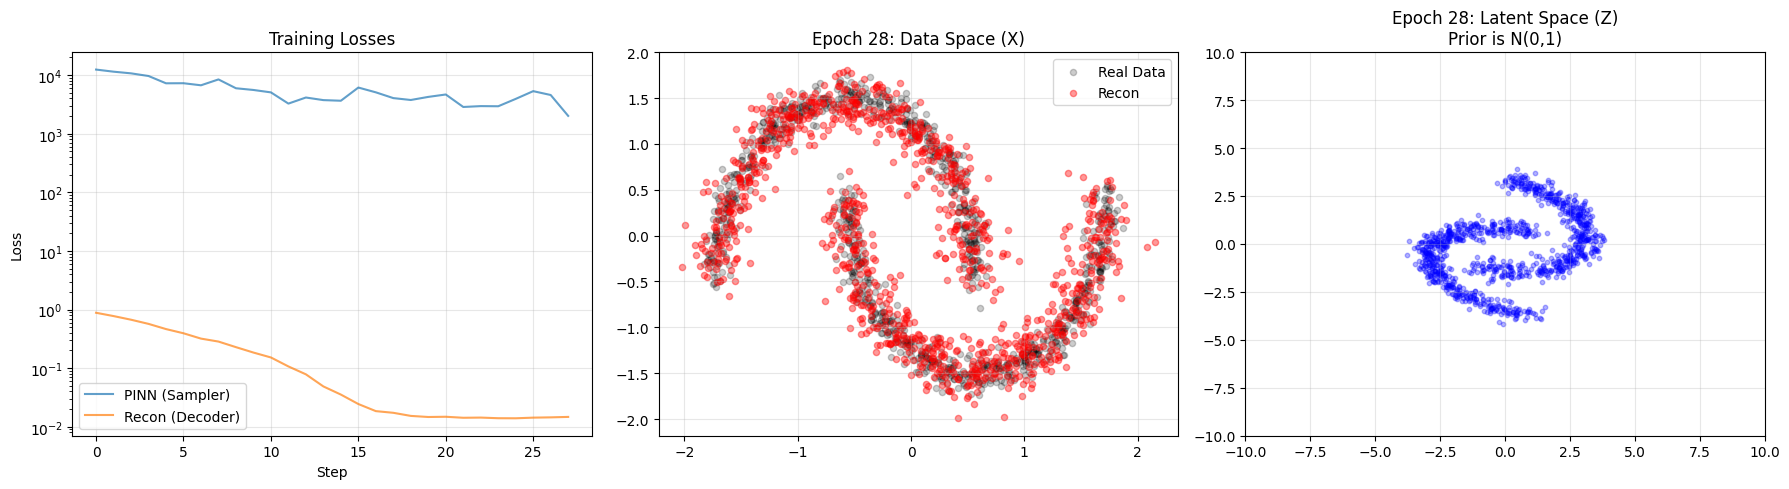

In [27]:
train_nets(
    device=device,
    data_loader=loader,
    nets=nets,
    decoder=decoder,
    opt_nets=opt_nets,
    opt_decoder=opt_decoder,
    z_dim=z_dim,
    epochs=100,
    sigma_schedule=False,
    sigma_start=0.3,
    sigma_end=0.1,
)